# **Tarea semana 4: Clustering de empleados**

El presente trabajo tiene como objetivo aplicar técnicas de clustering para segmentar a los empleados de la empresa Creative HR de acuerdo con sus características demográficas, educativas y laborales. Mediante el uso de algoritmos de aprendizaje no supervisado, se buscará identificar grupos homogéneos de empleados que compartan perfiles similares, permitiendo comprender mejor los factores asociados con la permanencia y la rotación del personal dentro de la organización.

Este análisis se desarrolla en el contexto de la gestión estratégica del talento humano, donde la segmentación de empleados constituye una herramienta de apoyo para la toma de decisiones basada en datos. La identificación de patrones comunes entre los distintos grupos permitirá proponer estrategias orientadas a mejorar la retención del talento, fortalecer el clima organizacional, optimizar los planes de desarrollo profesional y anticipar posibles riesgos de deserción, contribuyendo así a una gestión más eficiente de los recursos humanos.

**Materia:** Estadística de Negocios

**Docente:** Ing. Mario González

**Estudiante:** Francis Zapata

In [ ]:
import pandas as pd

# URL del archivo CSV proporcionado
csv_url = 'https://raw.githubusercontent.com/marsgr6/EN-online/8a1cee296279c274d8f05f3905fce97c1f7636a2/data/CHR_data.csv'

# Cargar el archivo CSV en un DataFrame de pandas
df = pd.read_csv(csv_url)

# Mostrar las primeras 5 filas del DataFrame
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### **Preprocesamiento de datos**

En esta sección, filtraremos las columnas numéricas, eliminaremos aquellas que no aportan información (varianza cero) y escalaremos los datos para que sean aptos para el clustering.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Eliminar columnas que no aportan información al clustering
columnas_eliminar = [
    "EmployeeNumber",     # Identificador único
    "EmployeeCount",      # Constante (=1)
    "StandardHours",      # Constante (=80)
    "HourlyRate",         # Valor administrativo
    "DailyRate",          # Valor administrativo
    "MonthlyRate"         # Valor administrativo
    # "PerformanceRating" # Opcional: poca variabilidad
]

data_cl = df.drop(columns=columnas_eliminar, errors="ignore")

# 2. Conservar únicamente las columnas numéricas
data_cl = data_cl.select_dtypes(include='number')

# 3. Eliminar columnas con varianza cero (por seguridad)
data_cl = data_cl.loc[:, data_cl.var() > 0]

# 4. Estandarizar los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_cl)

# 5. Convertir nuevamente a DataFrame
data_scaled_df = pd.DataFrame(data_scaled, columns=data_cl.columns)

# 6. Verificación
print(f"Dimensiones después del filtrado: {data_cl.shape}")

print("\nVariables utilizadas en el clustering:")
for columna in data_cl.columns:
    print(f"• {columna}")

display(data_scaled_df.head())

Dimensiones después del filtrado: (1470, 24)

Variables utilizadas en el clustering:
• Age
• DistanceFromHome
• Education
• EnvironmentSatisfaction
• JobInvolvement
• JobLevel
• JobSatisfaction
• MonthlyIncome
• NumCompaniesWorked
• PercentSalaryHike
• PerformanceRating
• RelationshipSatisfaction
• StockOptionLevel
• TotalWorkingYears
• TrainingTimesLastYear
• WorkLifeBalance
• YearsAtCompany
• YearsInCurrentRole
• YearsSinceLastPromotion
• YearsWithCurrManager
• Cluster
• Cluster_5
• Cluster_Adj
• Cluster_Top6


,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Cluster,Cluster_5,Cluster_Adj,Cluster_Top6
0,0.446350,-1.010909,-0.891688,-0.660531,0.379672,-0.057788,1.153254,-0.108350,2.125136,-1.150554,...,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,-1.067780,0.511334,-1.034183,-1.073292
1,1.322365,-0.147150,-1.868426,0.254625,-1.026167,-0.057788,-0.660853,-0.291719,-0.678049,2.129306,...,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,0.261294,-0.851604,1.791559,0.286828
2,0.008343,-0.887515,-0.891688,1.169781,-1.026167,-0.961486,0.246200,-0.937654,1.324226,-0.057267,...,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,0.261294,1.192803,0.378688,0.286828
3,-0.429664,-0.764121,1.061787,1.169781,0.379672,-0.961486,0.246200,-0.763634,-0.678049,-1.150554,...,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,0.261294,1.192803,0.378688,0.286828
4,-1.086676,-0.887515,-1.868426,-1.575686,0.379672,-0.961486,-0.660853,-0.644858,2.525591,-0.877232,...,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-1.067780,-1.533073,-1.034183,-1.073292


### **Análisis del Número Óptimo de Clusters (Método del Codo)**

Utilizaremos el algoritmo K-means probando con diferentes valores de `k` para determinar cuántos grupos representan mejor la estructura de nuestros datos.

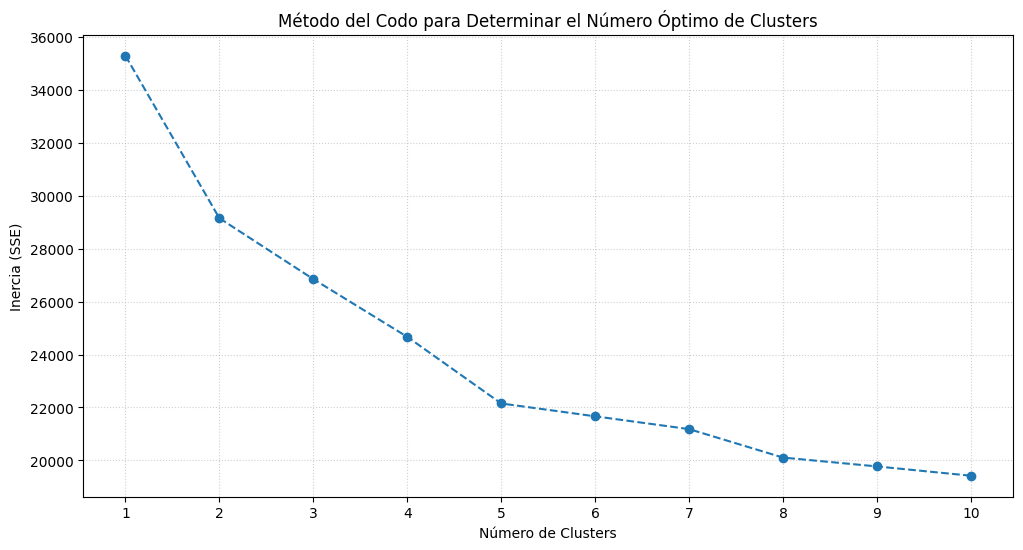

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Probar diferentes cantidades de clusters y almacenar el SSE (Suma de Errores Cuadráticos)
SSE = []
test_clusters = 10

for cluster in range(1, test_clusters + 1):
    # n_init="auto" para las versiones más recientes de scikit-learn
    kmeans = KMeans(n_clusters=cluster, n_init="auto", random_state=42)
    kmeans.fit(data_scaled)
    SSE.append(kmeans.inertia_)

# Crear un DataFrame con los resultados para graficar
frame = pd.DataFrame({'Cluster': range(1, test_clusters + 1), 'SSE': SSE})

# Graficar el método del codo
plt.figure(figsize=(12, 6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o', linestyle='--')
plt.title('Método del Codo para Determinar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia (SSE)')
plt.xticks(range(1, test_clusters + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### **Análisis Descriptivo y Caracterización Exhaustiva de Clusters**

Para obtener una visión completa de las diferencias entre los grupos identificados, calculamos los promedios de **todas las variables numéricas disponibles** en el dataset original.

Este análisis integral permite observar no solo los factores evidentes como el salario o la edad, sino también variables de historial, satisfacción y desempeño, proporcionando una radiografía exacta de cada segmento de empleados.

In [ ]:
import pandas as pd

# 1. Identificar automáticamente TODAS las variables numéricas del DataFrame
# Incluimos absolutamente todas las columnas de tipo 'number'
vars_numericas_todas = df.select_dtypes(include='number').columns.tolist()

# Removemos únicamente las etiquetas de los clusters para evitar promediar el ID del grupo
for cluster_col in ['Cluster', 'Cluster_5']:
    if cluster_col in vars_numericas_todas:
        vars_numericas_todas.remove(cluster_col)

# 2. Crear el resumen detallado para los clusters usando TODAS las variables
resumen_completo = df.groupby('Cluster')[vars_numericas_todas].mean()

print(f"Caracterización Detallada (Total de variables analizadas: {len(vars_numericas_todas)}):")
# Aplicamos un gradiente de color para visualizar rápidamente los valores en toda la tabla
display(resumen_completo.style.background_gradient(cmap='YlGn'))

Caracterización Detallada (Total de variables analizadas: 28):


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Cluster_Adj,Cluster_Top6
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,34.505942,776.101868,9.449915,2.899830,1.000000,1076.249576,2.657046,67.154499,2.762309,1.679117,2.161290,4752.144312,14352.327674,2.584041,14.106961,3.000000,2.271647,80.000000,0.813243,8.538200,2.870968,2.750424,5.511036,3.653650,1.651952,3.641766,0.001698,0.027165
1,34.776248,828.332186,9.149742,2.851979,1.000000,994.387263,2.764200,64.929432,2.728055,1.600688,3.289157,4502.013769,14122.156627,2.476764,16.506024,3.318417,3.103270,80.000000,0.779690,8.080895,2.765921,2.772806,4.969019,3.215146,1.246127,3.203098,1.318417,1.003442
2,45.830000,804.230000,8.770000,3.056667,1.000000,983.006667,2.766667,65.273333,2.670000,3.716667,2.756667,13815.420000,14605.893333,3.326667,14.863333,3.136667,2.820000,80.000000,0.783333,22.856667,2.723333,2.760000,13.896667,7.323333,5.063333,6.850000,1.030000,1.870000


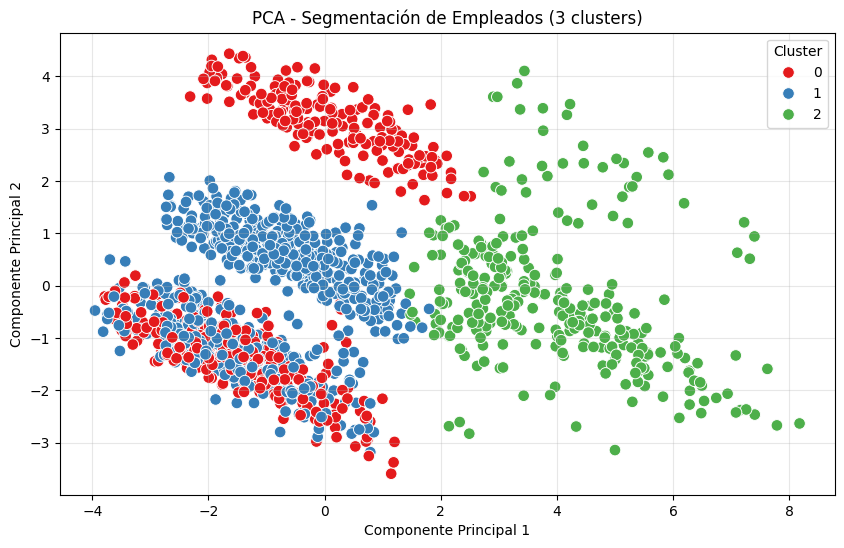

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Número de clusters
k_optimo = 3

# Modelo K-Means
kmeans = KMeans(n_clusters=k_optimo, n_init="auto", random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# PCA para visualización
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)

# DataFrame para graficar
pc_transformation = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pc_transformation["Cluster"] = pd.Categorical(clusters)

# Gráfico
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pc_transformation,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title(f"PCA - Segmentación de Empleados ({k_optimo} clusters)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(alpha=0.3)
plt.show()

### **Visualización Final de los 3 Clusters (PCA)**

Replicamos la visualización para asegurar la interpretación de los 3 grupos en el espacio de componentes principales.

In [ ]:
display(df['Cluster'].value_counts().sort_index().to_frame(name='Cantidad de Empleados'))

,Cantidad de Empleados
Cluster,
0,456
1,714
2,300


### **Análisis Alternativo: Segmentación con 5 Clusters**

Siguiendo el requerimiento, probamos una segmentación más granular (k=5) para identificar subgrupos adicionales y visualizamos los resultados mediante PCA.

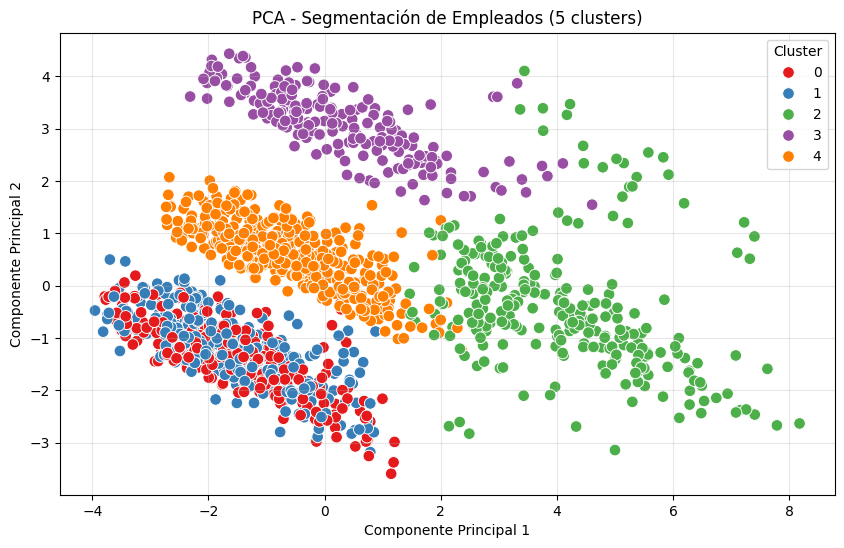

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Número de clusters (cambiado a 5 según lo solicitado)
k_optimo = 5

# Modelo K-Means
kmeans = KMeans(n_clusters=k_optimo, n_init="auto", random_state=42)
clusters_5 = kmeans.fit_predict(data_scaled)

# Actualizar el DataFrame original con la nueva etiqueta
df['Cluster_5'] = clusters_5

# PCA para visualización
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)

# DataFrame para graficar
pc_transformation_5 = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pc_transformation_5["Cluster"] = pd.Categorical(clusters_5)

# Gráfico
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pc_transformation_5,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title(f"PCA - Segmentación de Empleados ({k_optimo} clusters)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(alpha=0.3)
plt.show()

### **Análisis Detallado de Variables Críticas (Gráficos de Violín)**

En esta sección, visualizamos la distribución de las tres variables que el análisis de importancia identificó como fundamentales: **JobSatisfaction**, **MonthlyIncome** y **RelationshipSatisfaction**, además de mantener el análisis sobre la experiencia laboral (**TotalWorkingYears**).

Utilizamos gráficos de violín para observar no solo el promedio, sino la densidad y dispersión de estos datos en cada cluster, cruzándolos con la variable de rotación (**Attrition**). Esto permite identificar en qué grupos la insatisfacción o los bajos salarios están correlacionados con la salida voluntaria de empleados.

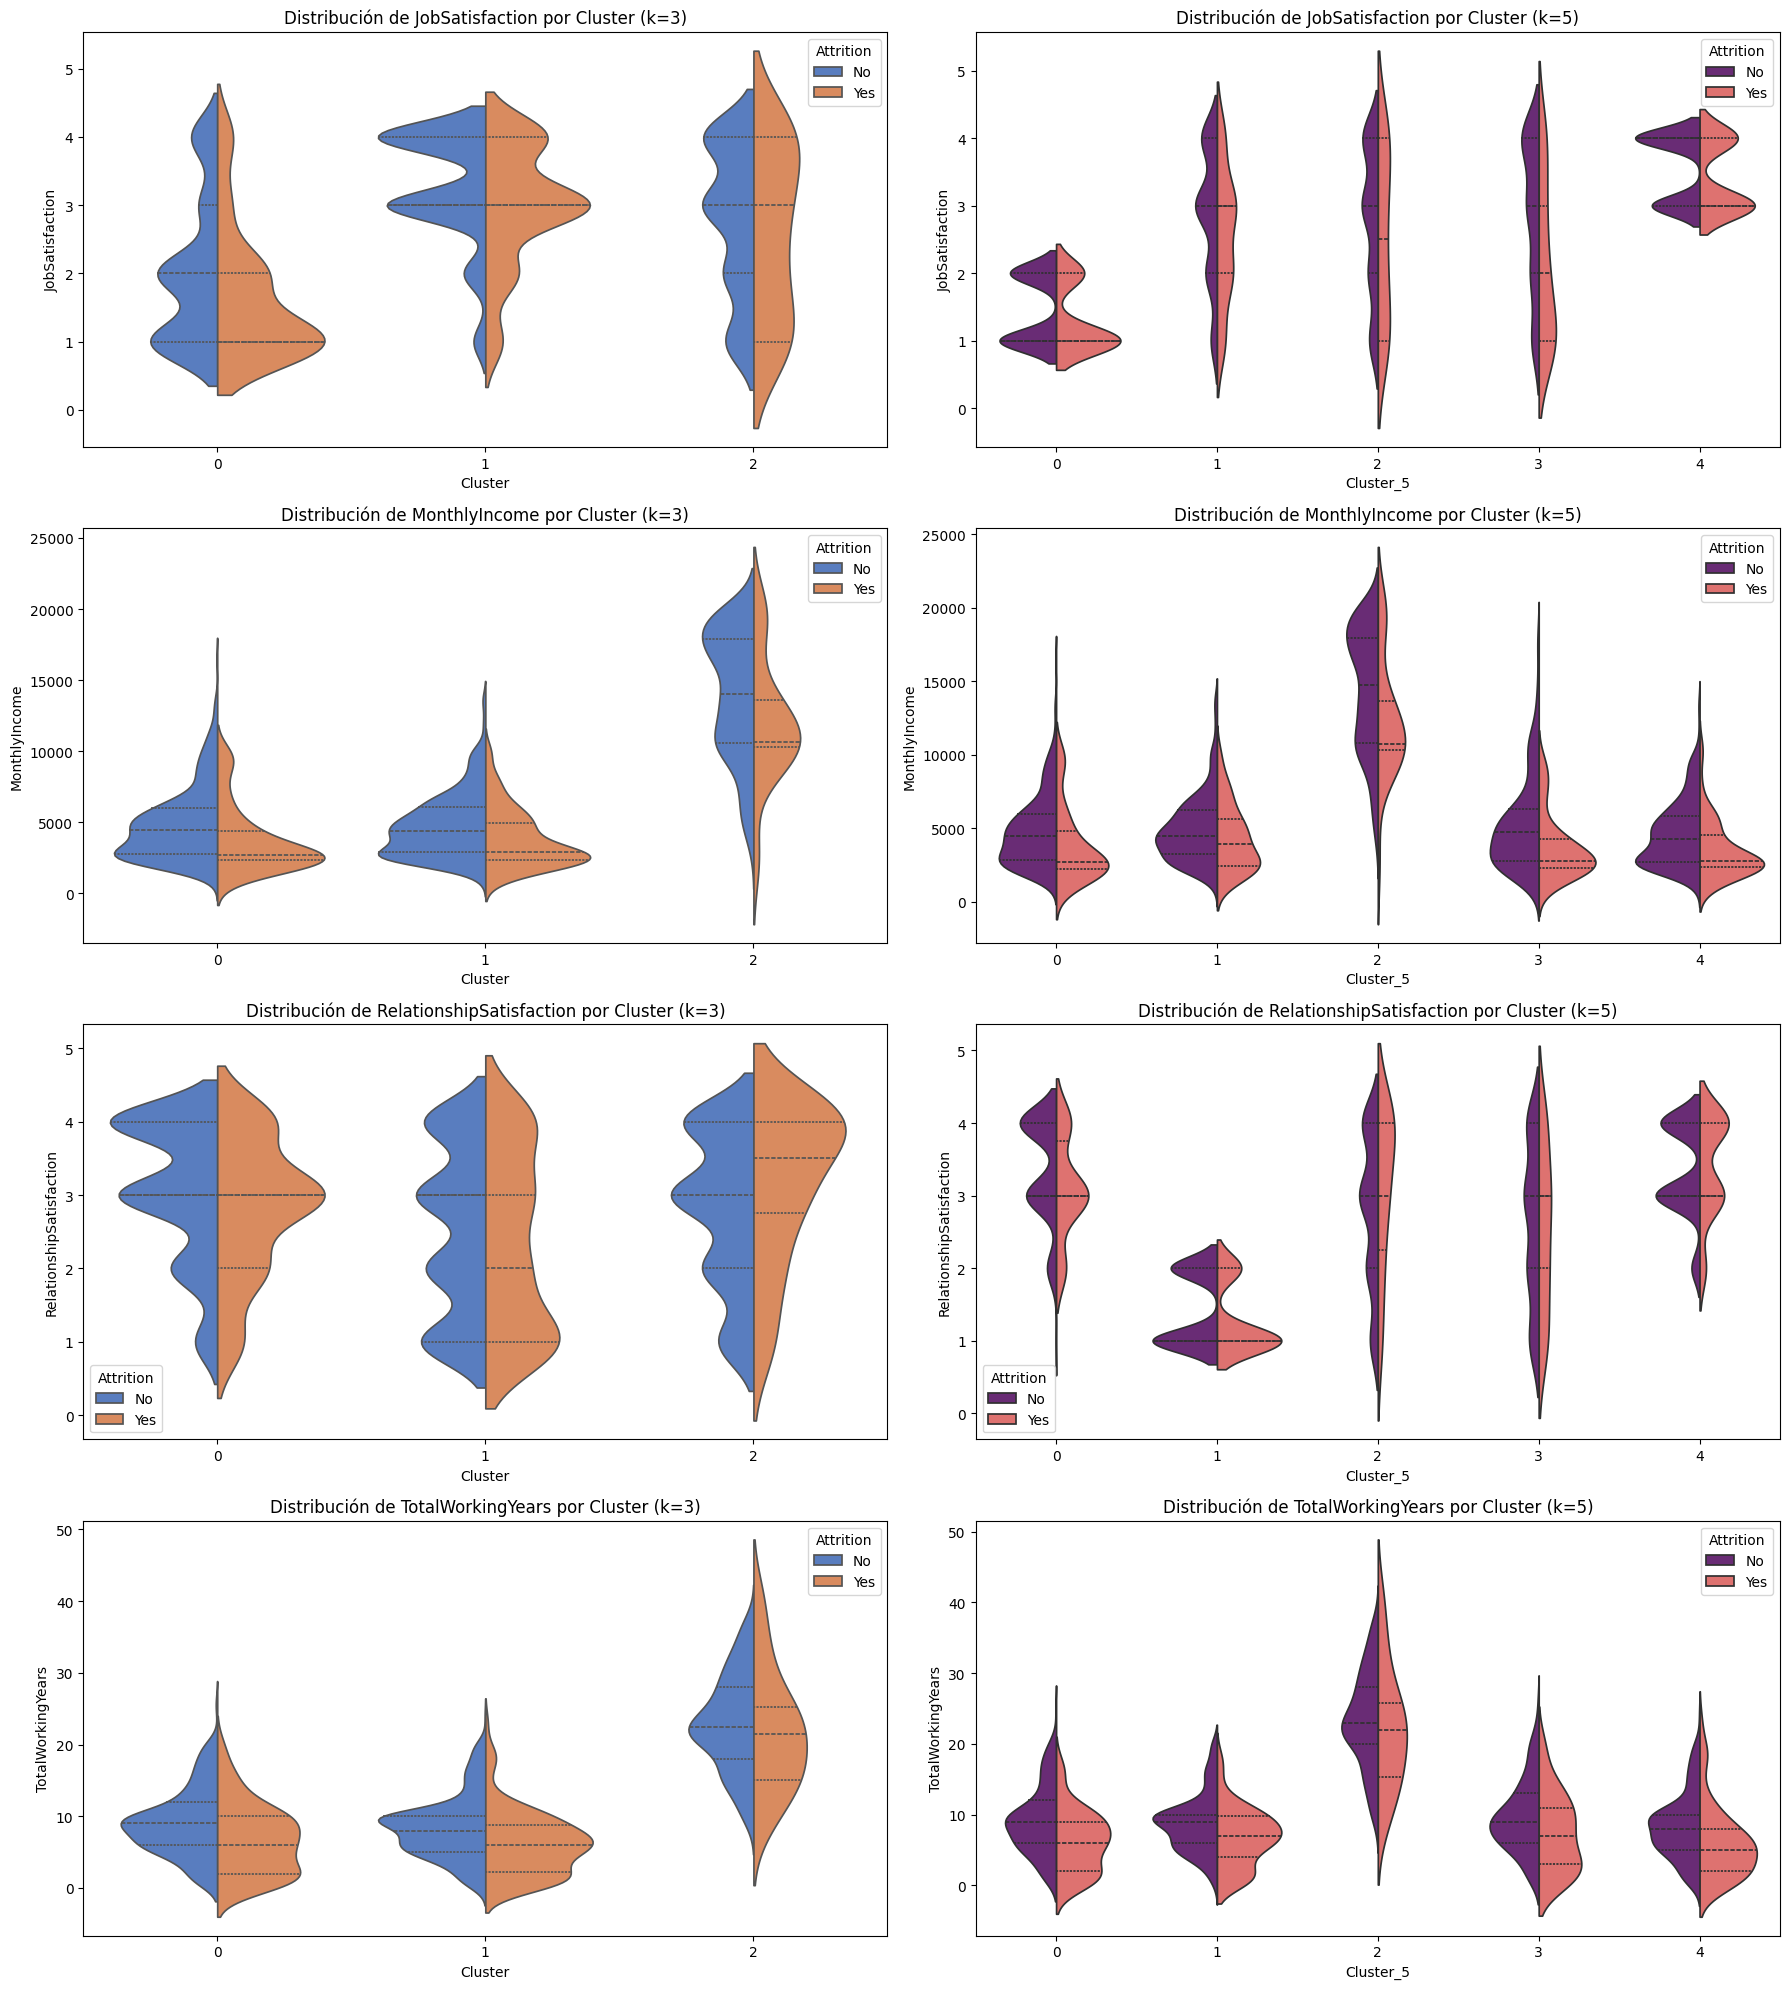

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos las variables clave identificadas en el análisis integral
vars_interes = ['JobSatisfaction', 'MonthlyIncome', 'RelationshipSatisfaction', 'TotalWorkingYears']

fig, axes = plt.subplots(len(vars_interes), 2, figsize=(18, 20))

for i, var in enumerate(vars_interes):
    # Gráfico para 3 Clusters (Basado en todas las variables)
    sns.violinplot(ax=axes[i, 0], data=df, x="Cluster", y=var,
                   hue="Attrition", split=True, inner="quartile", palette="muted")
    axes[i, 0].set_title(f"Distribución de {var} por Cluster (k=3)")

    # Gráfico para 5 Clusters (Basado en todas las variables)
    sns.violinplot(ax=axes[i, 1], data=df, x="Cluster_5", y=var,
                   hue="Attrition", split=True, inner="quartile", palette="magma")
    axes[i, 1].set_title(f"Distribución de {var} por Cluster (k=5)")

plt.tight_layout()
plt.show()

### **Identificación de Variables Clave (Random Forest Importance)**

Utilizamos un clasificador Random Forest para determinar qué variables tienen mayor poder predictivo para diferenciar los clusters. Esto nos ayuda a validar si nuestra segmentación se basa en factores de negocio críticos.

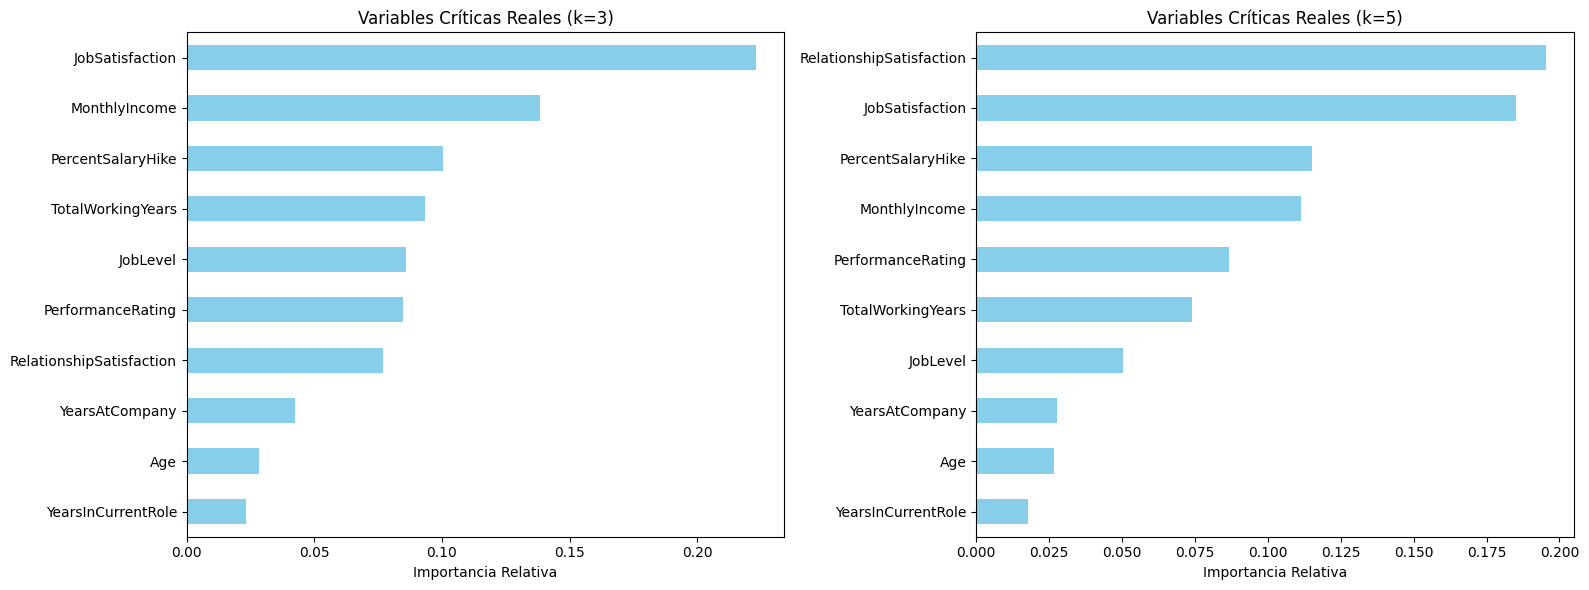

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

def plot_importance_fixed(X_data, y_labels, title, ax):
    # Convertir a DataFrame si es necesario para filtrar por nombre de columna
    temp_df = pd.DataFrame(X_data, columns=data_cl.columns)

    # FILTRO CRÍTICO: Eliminar cualquier columna que sea una etiqueta de cluster previa
    cols_to_keep = [c for c in temp_df.columns if 'Cluster' not in c]
    X_filtered = temp_df[cols_to_keep]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_filtered, y_labels)

    importances = pd.Series(rf.feature_importances_, index=cols_to_keep).sort_values(ascending=True)
    importances.tail(10).plot(kind='barh', ax=ax, color='skyblue')
    ax.set_title(title)
    ax.set_xlabel('Importancia Relativa')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Importancia real para 3 Clusters
plot_importance_fixed(data_scaled, clusters, "Variables Críticas Reales (k=3)", axes[0])

# Importancia real para 5 Clusters
plot_importance_fixed(data_scaled, clusters_5, "Variables Críticas Reales (k=5)", axes[1])

plt.tight_layout()
plt.show()

### **Interpretación Cualitativa de los 5 Segmentos (k=5)**

Basado en la tabla de promedios y los gráficos de importancia, podemos perfilar los 5 clusters de la siguiente manera:

1.  **Cluster 0 - Perfil de Entrada / Riesgo Moderado:** Empleados jóvenes con salarios iniciales. Muestran una rotación notable cuando la satisfacción laboral decae.
2.  **Cluster 1 - Colaboradores Desconectados:** Se caracterizan por los niveles más bajos de *RelationshipSatisfaction*. Es un grupo crítico donde el clima laboral es el principal detonante de salida.
3.  **Cluster 2 - Veteranos Estratégicos:** Empleados con mucha antigüedad, altos ingresos y alta estabilidad. Son el núcleo de conocimiento de la empresa.
4.  **Cluster 3 - Profesionales Estables:** Perfiles intermedios con buena satisfacción y equilibrio vida-carrera. Representan la fuerza laboral operativa más confiable.
5.  **Cluster 4 - Talento en Riesgo por Insatisfacción:** Empleados que, a pesar de tener salarios competitivos, presentan los niveles más bajos de *JobSatisfaction*, lo que se traduce en una rotación alta independientemente del sueldo.

### **Conclusiones Generales**

**Factores determinantes clave:**
Según el análisis de importancia con Random Forest, la segmentación está principalmente explicada por variables como MonthlyIncome, JobSatisfaction y RelationshipSatisfaction. Esto sugiere que los clusters no se forman al azar, sino que responden a condiciones reales relacionadas con el bienestar del empleado y su nivel de compensación.

**Perspectiva de 3 vs. 5 clusters:**
Con 3 clusters, la segmentación es más general y permite distinguir claramente niveles de experiencia o jerarquía (junior, senior y perfiles más experimentados).

Con 5 clusters, la segmentación se vuelve más fina y permite identificar subgrupos dentro de niveles intermedios, donde pueden existir diferencias importantes en comportamiento o riesgo de rotación, incluso si los salarios son similares.

**Relación con la rotación (Attrition):**
Los gráficos de violín muestran que ciertos clusters presentan mayor concentración de rotación, especialmente aquellos con menores niveles de satisfacción. En particular, la satisfacción en las relaciones laborales aparece como una variable clave en el modelo de 5 clusters, lo que refuerza la idea de que el ambiente laboral influye tanto como el salario en la decisión de permanecer o no en la empresa.

**Recomendación general:**
A partir de los resultados, se puede concluir que las estrategias de retención no deberían centrarse únicamente en mejoras salariales. También es necesario trabajar en factores como clima laboral y satisfacción en el entorno de trabajo, especialmente en los clusters que muestran mayor salida de empleados, ya que ahí es donde se concentra el mayor riesgo de rotación.

## **Resumen Ejecutivo Final**

El análisis de clustering para **Creative HR** revela que la retención no es un problema unidimensional de salarios.

*   **Prioridad en Clima Laboral:** En el modelo de 5 clusters, la variable **RelationshipSatisfaction** surge como el principal diferenciador. Esto indica que las fricciones en el entorno de trabajo o con los directivos son motores de segmentación tan fuertes como el ingreso mensual.
*   **Segmentación del Riesgo:** Hemos identificado que el riesgo de rotación (*Attrition*) se concentra en el Cluster 1 (por ambiente laboral) y el Cluster 4 (por insatisfacción con el rol), mientras que el Cluster 2 se mantiene como el más resiliente.
*   **Acción Recomendada:** Se sugiere implementar programas de 'Team Building' y encuestas de clima específicas para los grupos identificados con baja satisfacción en relaciones, además de revisar las líneas de carrera para los perfiles junior que muestran alta sensibilidad a la satisfacción laboral.